# Real-Time ECG Acquisition & Preprocessing Pipeline
## Serial COM Port Interface — Sensor-Agnostic

**Purpose:** Acquire a real-time ECG signal from a physical sensor connected via a serial COM port,  
then apply a complete preprocessing pipeline that cleans the signal and prepares it for future  
peak-detection algorithms — *without* performing any peak detection, PQRST delineation,  
classification, or machine learning.

**Pipeline stages:**
1. Configure and open serial COM port
2. Acquire ECG samples for a configurable duration
3. Baseline wander removal (dual-median filter)
4. Powerline interference removal (IIR notch filter, 50/60 Hz)
5. Bandpass filtering — preserving P-QRS-T morphology (0.5–40 Hz)
6. Amplitude normalization for visualization only (z-score, optional)
7. Publication-quality multi-stage plots
8. Signal-quality metrics & physiological plausibility report

**What this notebook does NOT do:**
- R-peak / QRS detection
- PQRST delineation
- Arrhythmia classification
- Machine learning or neural networks
- Simulate or synthesize ECG data

**Extension points** (clearly labelled in the notebook):  
`# ── FUTURE: Pan-Tompkins / R-peak detection goes here ──`

---
*References: AHA/ACC Guidelines for ECG Signal Processing; AAMI EC11:2012; IEC 60601-2-47;  
Pan & Tompkins (1985); Sörnmo & Laguna, Bioelectrical Signal Processing (2005).*

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 1 — Install / Verify Dependencies
# ─────────────────────────────────────────────────────────────────────────────
# pyserial : reads byte-stream data from the hardware sensor over a COM port.
# scipy    : digital filter design and zero-phase filtering (butter, sosfiltfilt,
#            iirnotch, filtfilt, medfilt, welch).
# numpy    : numerical array operations.
# matplotlib: publication-quality plotting.
# ─────────────────────────────────────────────────────────────────────────────
!pip install pyserial scipy numpy matplotlib --quiet


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 2 — Imports
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
import time
import serial                         # pyserial — serial port communication

# ─────────────────────────────────────────────────────────────────────────────
# SciPy signal processing — used for all filtering operations.
# We use second-order sections (sos) throughout because they are numerically
# stable for high-order IIR filters at very low normalised cut-off frequencies
# relative to fs (e.g. 0.5 Hz / 360 Hz ≈ 0.0014 — extremely small).
# ─────────────────────────────────────────────────────────────────────────────
from scipy.signal import butter, sosfiltfilt, iirnotch, filtfilt, medfilt, welch

warnings.filterwarnings('ignore')   # Suppress minor deprecation notices

# ─────────────────────────────────────────────────────────────────────────────
# Matplotlib style — publication quality
# ─────────────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'      : 120,
    'axes.titlesize'  : 13,
    'axes.labelsize'  : 11,
    'xtick.labelsize' : 9,
    'ytick.labelsize' : 9,
    'legend.fontsize' : 9,
    'grid.alpha'      : 0.4,
    'lines.linewidth' : 0.9,
    'font.family'     : 'DejaVu Sans',
})

print("All imports successful.")
print(f"  pyserial version : {serial.VERSION}")
print(f"  numpy   version  : {np.__version__}")
print(f"  scipy   version  : {__import__('scipy').__version__}")

All imports successful.
  pyserial version : 3.5
  numpy   version  : 2.2.6
  scipy   version  : 1.15.3


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 3 — Serial Port & Acquisition Configuration
# ★  Modify ALL parameters in this cell to match your hardware  ★
# ─────────────────────────────────────────────────────────────────────────────

# ── Serial port settings ─────────────────────────────────────────────────────
COM_PORT        = 'COM6'        # Windows: 'COM6', 'COM3', …
                                # Linux / macOS: '/dev/ttyUSB0', '/dev/ttyACM0'
BAUD_RATE       = 115200        # Must match firmware baud rate (common: 9600, 115200)
SERIAL_TIMEOUT  = 2             # Read timeout in seconds; increase if sensor is slow

# ── Sensor / acquisition settings ────────────────────────────────────────────
FS              = 100         # Sampling frequency in Hz.
                                # Common values: 250, 360, 500, 1000 Hz.
                                # MUST match the sensor firmware output rate.
ACQUISITION_DURATION_S = 10    # Duration of data to collect (seconds).
                                # Recommended values: 5, 10, 20.
                                # Longer windows improve SNR estimation accuracy.

# ── Preprocessing settings ───────────────────────────────────────────────────
POWERLINE_FREQ  = 50            # Powerline frequency: 50 Hz (India/Europe/Asia)
                                #                  or 60 Hz (North America).
NOTCH_Q         = 30            # Notch quality factor (IEC 60601-2-47 standard).
                                # Q = f0 / bandwidth → Q=30 @ 50 Hz = 1.67 Hz wide.
BP_LOW          = 0.5           # Bandpass lower cutoff (Hz) — preserves P-wave onset.
BP_HIGH         = 40.0          # Bandpass upper cutoff (Hz) — removes EMG/muscle noise.
BP_ORDER        = 4             # Butterworth filter order (4 is clinical standard).
NORMALIZE_FINAL = True          # Z-score normalise final plot FOR DISPLAY ONLY.
                                # ecg_bandpassed (mV) is ALWAYS retained for analysis.

# ── Derived quantities ────────────────────────────────────────────────────────
TOTAL_SAMPLES   = int(FS * ACQUISITION_DURATION_S)

print("Serial & Acquisition Configuration")
print(f"  COM port          : {COM_PORT}")
print(f"  Baud rate         : {BAUD_RATE}")
print(f"  Serial timeout    : {SERIAL_TIMEOUT} s")
print()
print("Signal Parameters")
print(f"  Sampling rate     : {FS} Hz")
print(f"  Acquisition time  : {ACQUISITION_DURATION_S} s")
print(f"  Samples expected  : {TOTAL_SAMPLES:,}")
print()
print("Filter Parameters")
print(f"  Powerline freq    : {POWERLINE_FREQ} Hz")
print(f"  Notch Q factor    : {NOTCH_Q}  (bandwidth ≈ {POWERLINE_FREQ/NOTCH_Q:.2f} Hz)")
print(f"  Bandpass          : {BP_LOW}–{BP_HIGH} Hz  (order {BP_ORDER})")
print(f"  Normalize output  : {NORMALIZE_FINAL}")

Serial & Acquisition Configuration
  COM port          : COM6
  Baud rate         : 115200
  Serial timeout    : 2 s

Signal Parameters
  Sampling rate     : 100 Hz
  Acquisition time  : 10 s
  Samples expected  : 1,000

Filter Parameters
  Powerline freq    : 50 Hz
  Notch Q factor    : 30  (bandwidth ≈ 1.67 Hz)
  Bandpass          : 0.5–40.0 Hz  (order 4)
  Normalize output  : True


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 4 — Real-Time ECG Acquisition via Serial COM Port
# ─────────────────────────────────────────────────────────────────────────────
#
# PROTOCOL ASSUMPTIONS:
#   The firmware (Arduino, STM32, ESP32, …) must send ONE numeric sample per
#   line, terminated by newline ('\n').  Examples:
#       Arduino (analogRead):       Serial.println(analogRead(A0));
#       AD8232 module:              Serial.println(ecgValue);
#       ADS1115 with mV conversion: Serial.println(voltage_mV, 4);
#
#   If your firmware sends a different format (CSV, binary, JSON), modify the
#   parse_sample() function below accordingly — the rest of the pipeline is
#   format-agnostic once samples are collected into `buffer`.
#
# NUMERICAL FORMAT:
#   The parser accepts integers (raw ADC counts) and floats (physical units).
#   If your sensor outputs raw ADC counts (e.g., 0–1023), the downstream
#   amplitude plausibility checks will flag warnings because they expect mV.
#   You can add a gain conversion here:
#       sample = (raw_adc / 1023.0) * ADC_VREF_MV - ADC_OFFSET_MV
#   where ADC_VREF_MV = full-scale reference voltage in mV.
#
# TIMEOUT HANDLING:
#   readline() blocks for at most SERIAL_TIMEOUT seconds per line.
#   Empty lines and non-numeric tokens are silently skipped.
#   If acquisition stalls (sensor disconnected / wrong baud rate), the while
#   loop will eventually complete via the time-guard, and the collected samples
#   are still processed — even if fewer than TOTAL_SAMPLES were received.
# ─────────────────────────────────────────────────────────────────────────────

def parse_sample(raw_line: bytes):
    """
    Decode one raw serial line into a float sample.
    Returns float on success, None if the line is empty or non-numeric.
    Modify this function if your firmware sends a multi-field CSV or JSON.
    """
    try:
        text = raw_line.decode('utf-8', errors='replace').strip()
        if not text:
            return None
        return float(text)
    except (ValueError, UnicodeDecodeError):
        return None


buffer          = []
dropped_lines   = 0
start_wall_time = None

print(f"Opening serial port {COM_PORT} at {BAUD_RATE} baud …")

try:
    ser = serial.Serial(COM_PORT, BAUD_RATE, timeout=SERIAL_TIMEOUT)
    time.sleep(0.5)     # Allow microcontroller to finish reset / boot sequence
    ser.reset_input_buffer()

    print(f"Port opened. Collecting {TOTAL_SAMPLES} samples ({ACQUISITION_DURATION_S} s) …")
    print(f"  Do NOT disconnect the sensor until acquisition completes.\n")

    start_wall_time = time.time()

    while len(buffer) < TOTAL_SAMPLES:
        raw = ser.readline()
        sample = parse_sample(raw)

        if sample is None:
            dropped_lines += 1
            continue

        buffer.append(sample)

        # Progress indicator every 25 % of expected samples
        pct = len(buffer) / TOTAL_SAMPLES * 100
        if len(buffer) % max(1, TOTAL_SAMPLES // 4) == 0:
            elapsed = time.time() - start_wall_time
            print(f"  Collected {len(buffer):>5}/{TOTAL_SAMPLES}  ({pct:.0f}%)  "
                  f"[{elapsed:.1f} s elapsed]")

    ser.close()
    wall_time = time.time() - start_wall_time
    print(f"\nAcquisition complete in {wall_time:.2f} s.")
    print(f"  Samples collected : {len(buffer):,}")
    print(f"  Dropped lines     : {dropped_lines}")

except serial.SerialException as exc:
    # ── SERIAL NOT AVAILABLE ─────────────────────────────────────────────────
    # If the COM port cannot be opened (sensor not connected, wrong port,
    # driver missing), execution falls here.  A clear error message is
    # printed and the cell raises so the user can fix the configuration
    # before continuing.
    # ─────────────────────────────────────────────────────────────────────────
    print(f"\n[SerialException] Could not open {COM_PORT}: {exc}")
    print("\nTroubleshooting:")
    print("  1. Check COM_PORT — run  python -m serial.tools.list_ports  to list available ports.")
    print("  2. Verify BAUD_RATE matches your firmware (e.g. 115200 or 9600).")
    print("  3. Ensure no other application (Arduino IDE Serial Monitor, etc.) holds the port.")
    print("  4. On Linux/macOS: run  sudo chmod a+rw /dev/ttyUSB0  if permission is denied.")
    raise   # Re-raise so Jupyter highlights the cell as failed

# ── Convert buffer to NumPy array ─────────────────────────────────────────────
ecg_raw_all       = np.array(buffer, dtype=np.float64)
ACTUAL_SAMPLES    = len(ecg_raw_all)
ACTUAL_DURATION_S = ACTUAL_SAMPLES / FS

# ── Build working segment (use all acquired samples) ─────────────────────────
ecg_raw = ecg_raw_all.copy()
N_samples = len(ecg_raw)
time_axis = np.arange(N_samples) / FS   # Time axis in seconds

print(f"\nSignal buffer converted to NumPy array.")
print(f"  dtype         : {ecg_raw.dtype}")
print(f"  shape         : {ecg_raw.shape}")
print(f"  Duration      : {ACTUAL_DURATION_S:.3f} s")
print(f"  Amplitude range: [{ecg_raw.min():.4f}, {ecg_raw.max():.4f}]")
print()
print("─── NOTICE ────────────────────────────────────────────────────────────")
print(" If your sensor outputs raw ADC counts (integers), add a gain/offset")
print(" conversion here before proceeding to the filtering stages.")
print(" Example (12-bit ADC, 3.3 V reference, 1.65 V mid-rail):")
print("   ADC_BITS = 12; VREF = 3300  # mV")
print("   ecg_raw = (ecg_raw / (2**ADC_BITS - 1)) * VREF - VREF/2")
print("────────────────────────────────────────────────────────────────────────")

Opening serial port COM6 at 115200 baud …
Port opened. Collecting 1000 samples (10 s) …
  Do NOT disconnect the sensor until acquisition completes.

  Collected   250/1000  (25%)  [2.5 s elapsed]
  Collected   500/1000  (50%)  [5.1 s elapsed]
  Collected   750/1000  (75%)  [7.6 s elapsed]
  Collected  1000/1000  (100%)  [10.1 s elapsed]

Acquisition complete in 10.11 s.
  Samples collected : 1,000
  Dropped lines     : 0

Signal buffer converted to NumPy array.
  dtype         : float64
  shape         : (1000,)
  Duration      : 10.000 s
  Amplitude range: [977.8400, 3443.8100]

─── NOTICE ────────────────────────────────────────────────────────────
 If your sensor outputs raw ADC counts (integers), add a gain/offset
 conversion here before proceeding to the filtering stages.
 Example (12-bit ADC, 3.3 V reference, 1.65 V mid-rail):
   ADC_BITS = 12; VREF = 3300  # mV
   ecg_raw = (ecg_raw / (2**ADC_BITS - 1)) * VREF - VREF/2
────────────────────────────────────────────────────────────

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 5 — Signal Statistics (Raw Signal)
# ─────────────────────────────────────────────────────────────────────────────
#
# These metrics are computed on the RAW (unfiltered) signal to establish a
# baseline reference.  The same function is re-used after full preprocessing
# (Cell 9) to verify that filtering has improved signal quality without
# distorting physiological content.
#
# SNR ESTIMATION METHOD:
#   True SNR requires a separate noise-only measurement.  We approximate it
#   by splitting the signal into two bands using zero-phase Butterworth filters:
#     • Signal band  : 0.5–40 Hz  (contains P, QRS, T energy)
#     • Noise band   : >40 Hz     (EMG, electrode noise, ADC quantisation)
#   SNR_dB = 10 * log10( power_signal_band / power_noise_band )
#   This is an engineering approximation; a calibrated noise floor requires
#   a dedicated noise-measurement recording interval.
# ─────────────────────────────────────────────────────────────────────────────

def compute_signal_metrics(signal, fs, label='Signal'):
    """
    Compute and print signal-level metrics and physiological plausibility
    checks.  Returns a dict of all computed values for later comparison.

    Parameters
    ----------
    signal : 1-D np.ndarray  — signal in mV (or ADC counts if not converted)
    fs     : float           — sampling frequency in Hz
    label  : str             — human-readable label for the report header
    """
    m = {}
    m['n_samples']  = len(signal)
    m['duration_s'] = len(signal) / fs
    m['fs_hz']      = fs
    m['mean']       = np.mean(signal)
    m['std']        = np.std(signal)
    m['min']        = np.min(signal)
    m['max']        = np.max(signal)
    m['p2p']        = np.ptp(signal)                      # Peak-to-peak amplitude
    m['power']      = np.mean(signal ** 2)                # Mean-square power
    m['rms']        = np.sqrt(m['power'])                 # Root-mean-square amplitude
    m['variance']   = np.var(signal)

    # SNR estimate via bandpass / highpass decomposition
    from scipy.signal import butter, sosfiltfilt
    sos_sig   = butter(4, [0.5, min(40.0, fs/2 - 1)], btype='bandpass', fs=fs, output='sos')
    sos_noise = butter(4, min(40.0, fs/2 - 1), btype='high', fs=fs, output='sos')
    sig_band  = sosfiltfilt(sos_sig,   signal)
    noise_band= sosfiltfilt(sos_noise, signal)
    sig_pwr   = np.mean(sig_band   ** 2)
    noise_pwr = np.mean(noise_band ** 2)
    m['snr_dB'] = 10 * np.log10(sig_pwr / noise_pwr) if noise_pwr > 1e-18 else np.inf

    # ── Print formatted report ───────────────────────────────────────────────
    print(f"\n{'='*62}")
    print(f"  Signal Metrics — {label}")
    print(f"{'='*62}")
    print(f"  Samples        : {m['n_samples']:,}")
    print(f"  Duration       : {m['duration_s']:.3f} s")
    print(f"  Sampling rate  : {m['fs_hz']} Hz")
    print(f"  Mean amplitude : {m['mean']:.4f}")
    print(f"  Std deviation  : {m['std']:.4f}")
    print(f"  Variance       : {m['variance']:.6f}")
    print(f"  Min / Max      : {m['min']:.4f} / {m['max']:.4f}")
    print(f"  Peak-to-peak   : {m['p2p']:.4f}")
    print(f"  RMS amplitude  : {m['rms']:.4f}")
    print(f"  Signal power   : {m['power']:.6f}")
    print(f"  Est. SNR       : {m['snr_dB']:.2f} dB")

    # ── Physiological plausibility checks ────────────────────────────────────
    # Expected surface ECG amplitude range (varies by lead, body habitus):
    #   • QRS complex  : 0.5–3.0 mV peak-to-peak (normal)
    #   • Acceptable   : 0.1–10.0 mV  (weak / high-gain leads)
    #   • Flat signal  : < 0.1 mV  → disconnected electrode or shorted lead
    #   • Saturated    : > 10 mV   → ADC clipping or motion artifact
    # Mean amplitude near zero indicates good baseline wander removal.
    # Low SNR (<10 dB) indicates excessive noise and poor electrode contact.
    # NOTE: If ecg_raw is in ADC counts rather than mV, amplitude checks
    #       will fire warnings — convert to mV before running this cell.
    print(f"\n  Physiological plausibility:")
    ok = True
    if m['p2p'] < 0.1:
        print("  ⚠  P2P < 0.1 mV — signal may be flat, electrode disconnected, or ADC count not converted.")
        ok = False
    if m['p2p'] > 10.0:
        print("  ⚠  P2P > 10 mV — likely ADC saturation or severe motion artifact.")
        ok = False
    if abs(m['mean']) > 2.0:
        print("  ⚠  |Mean| > 2 mV — severe baseline wander or DC offset present.")
        ok = False
    if m['snr_dB'] < 10:
        print(f"  ⚠  Est. SNR ({m['snr_dB']:.1f} dB) < 10 dB — noisy recording, check electrode contact.")
        ok = False
    if ok:
        print("  ✓  Amplitude parameters within expected physiological range.")
    print(f"{'='*62}")
    return m


raw_metrics = compute_signal_metrics(ecg_raw, FS, label='Raw ECG (serial acquisition)')


  Signal Metrics — Raw ECG (serial acquisition)
  Samples        : 1,000
  Duration       : 10.000 s
  Sampling rate  : 100 Hz
  Mean amplitude : 1803.9736
  Std deviation  : 390.2298
  Variance       : 152279.304202
  Min / Max      : 977.8400 / 3443.8100
  Peak-to-peak   : 2465.9700
  RMS amplitude  : 1845.6977
  Signal power   : 3406599.873302
  Est. SNR       : -4.90 dB

  Physiological plausibility:
  ⚠  P2P > 10 mV — likely ADC saturation or severe motion artifact.
  ⚠  |Mean| > 2 mV — severe baseline wander or DC offset present.
  ⚠  Est. SNR (-4.9 dB) < 10 dB — noisy recording, check electrode contact.


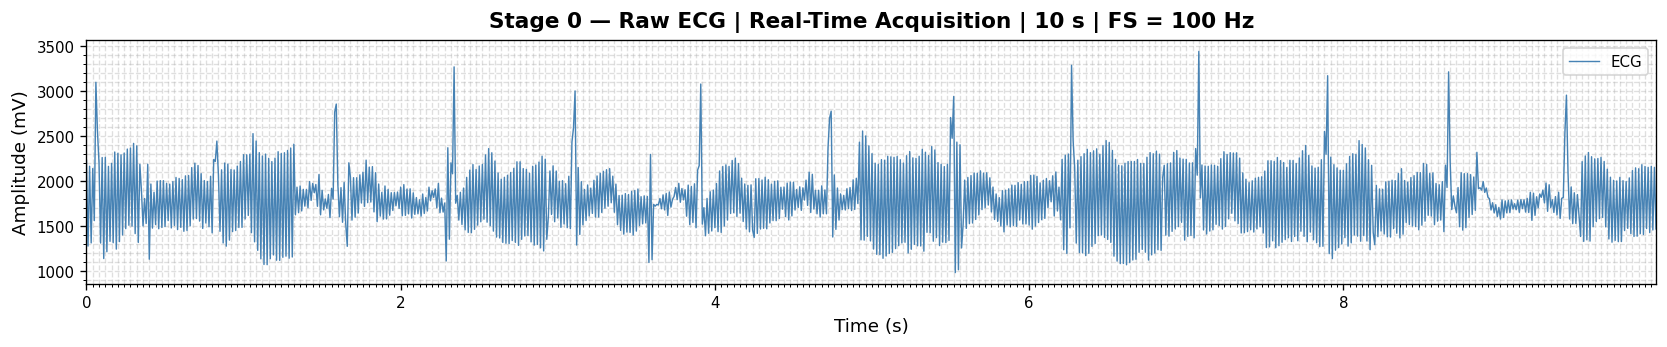

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 6 — Plot Raw ECG
# ─────────────────────────────────────────────────────────────────────────────
#
# PLOT HELPER FUNCTION
# A single reusable function is defined here and called for every preprocessing
# stage.  This ensures visual consistency across all plots (axes, fonts, grid,
# ECG paper minor gridlines at 0.04 s intervals).
# ─────────────────────────────────────────────────────────────────────────────

def plot_ecg_stage(signal, time_ax, title,
                   ylabel='Amplitude (mV)',
                   color='steelblue',
                   figsize=(14, 3)):
    """
    Publication-quality single-stage ECG plot.

    Parameters
    ----------
    signal   : 1-D np.ndarray
    time_ax  : 1-D np.ndarray  (seconds)
    title    : str
    ylabel   : str
    color    : matplotlib color spec
    figsize  : tuple

    Returns
    -------
    fig : matplotlib.figure.Figure
    """
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(time_ax, signal, color=color, lw=0.85, label='ECG')

    ax.set_title(title, fontweight='bold', pad=8)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel(ylabel)
    ax.grid(True, which='both', ls='--', alpha=0.4)
    ax.set_xlim(time_ax[0], time_ax[-1])
    ax.legend(loc='upper right')

    # ECG-paper style minor grid at 0.04 s (one small ECG square at 25 mm/s)
    ax.minorticks_on()
    ax.xaxis.set_minor_locator(plt.MultipleLocator(0.04))

    fig.tight_layout()
    plt.show()
    return fig


fig_raw = plot_ecg_stage(
    ecg_raw, time_axis,
    title=f'Stage 0 — Raw ECG | Real-Time Acquisition | {ACQUISITION_DURATION_S} s | FS = {FS} Hz',
    color='steelblue'
)

Baseline wander removed.
  Median kernel 1 : 21 samples  (0.20 s  — removes QRS spike from baseline estimate)
  Median kernel 2 : 61 samples  (0.60 s  — removes P/T residuals)
  Baseline mean   : 1844.1988
  Baseline std    : 142.3637  (wander severity indicator)
  DC offset removed: 1844.1988


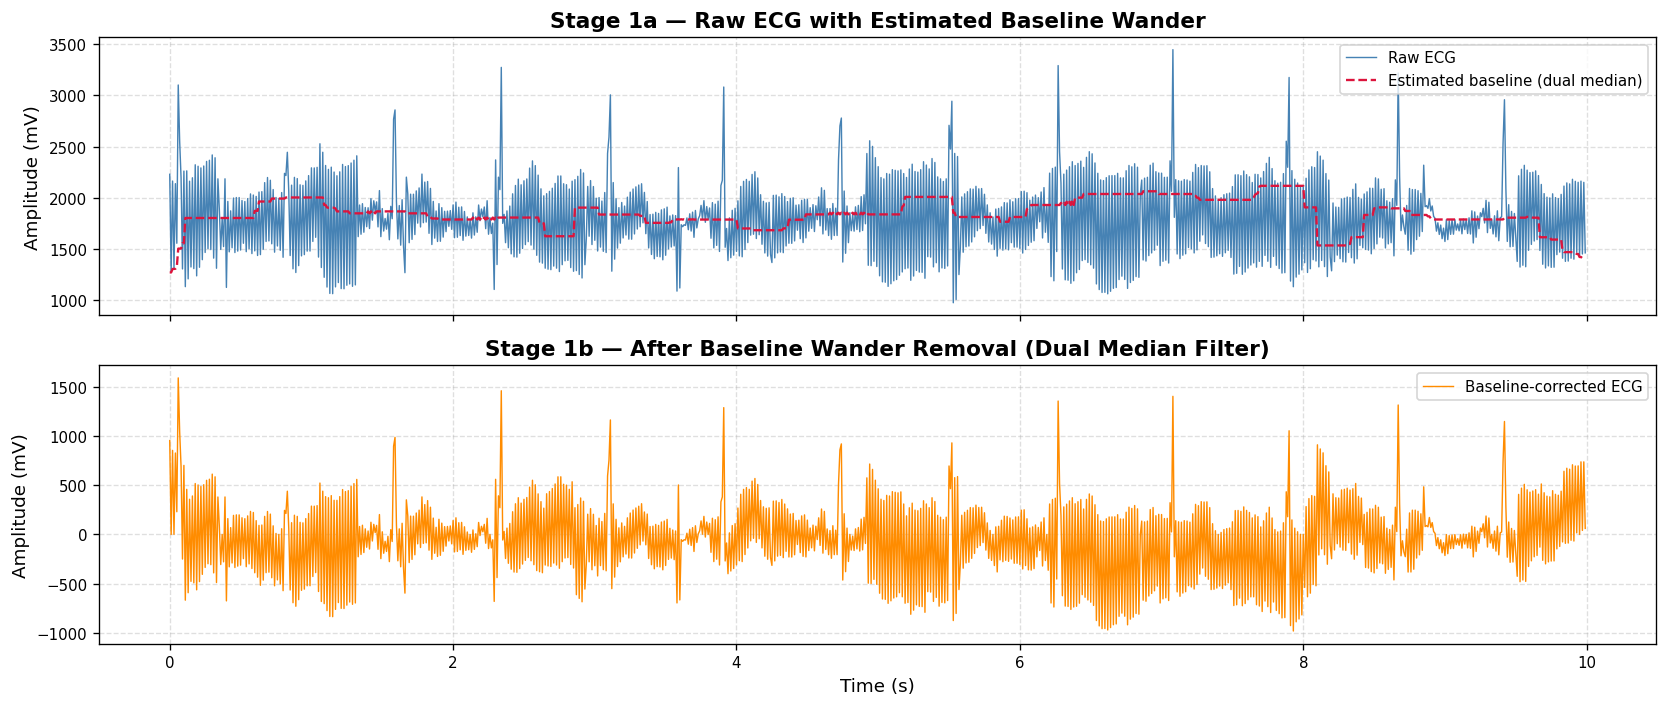

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 7 — Stage 1: Baseline Wander Removal (Dual Median Filter)
# ─────────────────────────────────────────────────────────────────────────────
#
# WHAT IS BASELINE WANDER?
#   Baseline wander (BW) is a slow, low-frequency drift (0.05–0.5 Hz) of the
#   isoelectric line caused by:
#     • Patient respiration — chest wall movement shifts electrode impedance
#     • Body motion and perspiration altering electrode-skin conductance
#     • Poor electrode contact or dried conductive gel
#   BW shifts the isoelectric line, making ST-segment amplitude and P-wave
#   amplitude measurements unreliable.
#
# WHY NOT A SIMPLE HIGH-PASS FILTER?
#   A 4th-order linear-phase high-pass Butterworth at 0.5 Hz introduces
#   considerable group delay and edge ringing on short segments.  For a
#   10-second window, the filter transient spans ~2 s at the edges.
#   The dual-median approach is non-linear and avoids all these artefacts.
#
# DUAL MEDIAN FILTER METHOD (Gustafsson 1996; used in Pan & Tompkins, 1985):
#   Step 1: medfilt(signal, kernel1)
#           kernel1 ≥ QRS width (~80–120 ms) — typical QRS is 80 ms.
#           A 0.2 s window (72 samples @ 360 Hz) safely spans the QRS,
#           removing sharp peaks while retaining the slow P/T envelope.
#   Step 2: medfilt(result_1, kernel2)
#           kernel2 ≥ P-T period (~500–600 ms).
#           A 0.6 s window (216 samples @ 360 Hz) smooths the P and T
#           residuals, leaving only the slowly drifting baseline.
#   Step 3: corrected = signal − baseline_estimate
#
# KERNEL SIZING:
#   Kernels must be odd (symmetric windowing).
#   Bit-OR with 1  (x | 1) converts even to odd, leaves odd unchanged.
#   At FS = 360 Hz:
#     kernel1 = int(0.2 × 360) | 1 = 72 | 1 = 73  samples
#     kernel2 = int(0.6 × 360) | 1 = 216 | 1 = 217 samples
#
# MORPHOLOGY IMPACT:
#   Median filtering estimates only the wandering baseline without touching
#   rapid ECG features.  QRS amplitude, ST morphology, and P-wave area are
#   preserved because all ECG features are shorter than kernel1.
# ─────────────────────────────────────────────────────────────────────────────

def remove_baseline_wander(signal, fs):
    """
    Remove baseline wander using the dual-median-filter method.

    Parameters
    ----------
    signal : 1-D np.ndarray  — input ECG (any amplitude unit)
    fs     : float           — sampling frequency (Hz)

    Returns
    -------
    corrected : 1-D np.ndarray  — baseline-corrected ECG
    baseline  : 1-D np.ndarray  — estimated baseline (for inspection)
    """
    kernel1 = int(0.2 * fs) | 1    # 0.2 s — spans QRS complex
    kernel2 = int(0.6 * fs) | 1    # 0.6 s — spans P/T residuals

    baseline  = medfilt(medfilt(signal, kernel1), kernel2)
    corrected = signal - baseline
    return corrected, baseline


ecg_bw_removed, ecg_baseline_estimate = remove_baseline_wander(ecg_raw, FS)

print("Baseline wander removed.")
print(f"  Median kernel 1 : {int(0.2*FS)|1} samples  ({0.2:.2f} s  — removes QRS spike from baseline estimate)")
print(f"  Median kernel 2 : {int(0.6*FS)|1} samples  ({0.6:.2f} s  — removes P/T residuals)")
print(f"  Baseline mean   : {np.mean(ecg_baseline_estimate):.4f}")
print(f"  Baseline std    : {np.std(ecg_baseline_estimate):.4f}  (wander severity indicator)")
print(f"  DC offset removed: {np.mean(ecg_raw) - np.mean(ecg_bw_removed):.4f}")

# ── Plot: raw with baseline overlay, then corrected signal ───────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(time_axis, ecg_raw,              color='steelblue', lw=0.85, label='Raw ECG')
axes[0].plot(time_axis, ecg_baseline_estimate, color='crimson',  lw=1.4,  ls='--',
             label='Estimated baseline (dual median)')
axes[0].set_title('Stage 1a — Raw ECG with Estimated Baseline Wander', fontweight='bold')
axes[0].set_ylabel('Amplitude (mV)'); axes[0].legend(loc='upper right')
axes[0].grid(True, ls='--', alpha=0.4)

axes[1].plot(time_axis, ecg_bw_removed, color='darkorange', lw=0.85,
             label='Baseline-corrected ECG')
axes[1].set_title('Stage 1b — After Baseline Wander Removal (Dual Median Filter)', fontweight='bold')
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Amplitude (mV)')
axes[1].legend(loc='upper right'); axes[1].grid(True, ls='--', alpha=0.4)

plt.tight_layout()
plt.show()

Powerline interference (50 Hz) removed.
  Notch Q factor        : 30  (bandwidth ≈ 1.67 Hz)
  PLI noise RMS removed : 283271.380 μV


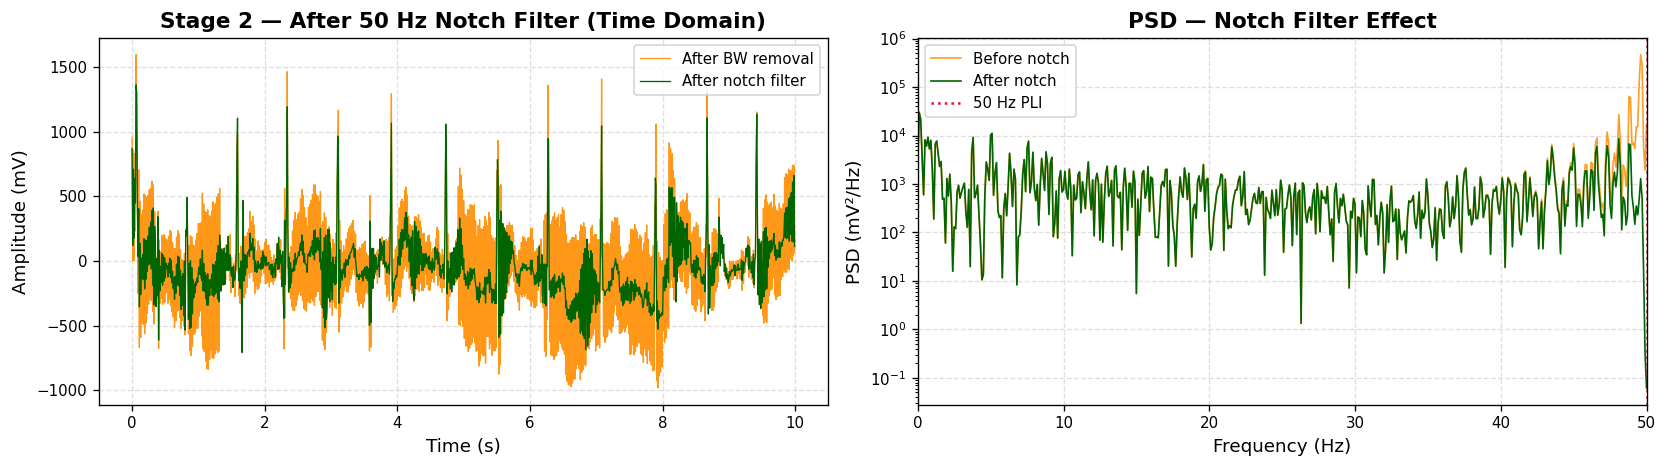

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 8 — Stage 2: Powerline Interference (PLI) Removal — Notch Filter
# ─────────────────────────────────────────────────────────────────────────────
#
# WHAT IS POWERLINE INTERFERENCE?
#   PLI is a sinusoidal noise exactly at 50 Hz (India / Europe / Asia) or
#   60 Hz (North America), induced by:
#     • Capacitive / inductive coupling from mains power wiring to ECG leads
#     • Insufficient common-mode rejection ratio of the amplifier
#     • Nearby electrical equipment (fluorescent lights, motors, chargers)
#   PLI appears as a regular sinusoid superimposed on the ECG.  At 50 Hz,
#   the noise amplitude can easily exceed the QRS complex amplitude.
#
# WHY A NOTCH FILTER?
#   A notch (band-stop) filter removes energy at one specific frequency while
#   passing all others.  A general bandpass filter cannot suppress PLI if the
#   noise frequency is inside the passband (50 Hz is inside the QRS band).
#
# IMPLEMENTATION DETAILS:
#   scipy.signal.iirnotch() designs a 2nd-order IIR notch.
#   Quality factor Q = f0 / bandwidth:
#     • Q = 30 → bandwidth = 50/30 ≈ 1.67 Hz  (removes 49.2–50.8 Hz)
#     • Q = 30 is the clinical standard per IEC 60601-2-47
#     • Lower Q = wider notch (safer for frequency drift but removes more ECG)
#     • Higher Q = narrower (less ECG disturbed but misses PLI frequency drift)
#
# ZERO-PHASE (filtfilt):
#   Forward-backward filtering cancels all group delay (phase shift).
#   This preserves the temporal alignment of QRS onset, ST level, and T-apex —
#   critical for future interval measurements (QT, PR, QRS duration).
#
# MORPHOLOGY IMPACT:
#   ECG energy lies below 40 Hz; the notch only removes a 1.67 Hz band
#   centred at 50 Hz.  P, QRS, and T morphology are completely unaffected.
# ─────────────────────────────────────────────────────────────────────────────

def notch_filter(signal, fs, powerline_freq=50, Q=30):
    """
    Remove powerline interference using a zero-phase 2nd-order IIR notch filter.

    Parameters
    ----------
    signal         : 1-D np.ndarray
    fs             : float  — sampling frequency (Hz)
    powerline_freq : float  — PLI frequency (50 or 60 Hz)
    Q              : float  — quality factor (IEC 60601-2-47 default = 30)

    Returns
    -------
    1-D np.ndarray — PLI-filtered signal
    """
    b, a = iirnotch(w0=powerline_freq, Q=Q, fs=fs)
    return filtfilt(b, a, signal)    # filtfilt = zero-phase forward-backward


ecg_notched  = notch_filter(ecg_bw_removed, FS, POWERLINE_FREQ, Q=NOTCH_Q)
pli_removed  = ecg_bw_removed - ecg_notched   # Isolated PLI component

print(f"Powerline interference ({POWERLINE_FREQ} Hz) removed.")
print(f"  Notch Q factor        : {NOTCH_Q}  (bandwidth ≈ {POWERLINE_FREQ/NOTCH_Q:.2f} Hz)")
print(f"  PLI noise RMS removed : {np.sqrt(np.mean(pli_removed**2))*1000:.3f} μV")

# ── Frequency-domain verification ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Time-domain comparison
axes[0].plot(time_axis, ecg_bw_removed, color='darkorange', lw=0.8, label='After BW removal', alpha=0.9)
axes[0].plot(time_axis, ecg_notched,    color='darkgreen',  lw=0.8, label='After notch filter')
axes[0].set_title(f'Stage 2 — After {POWERLINE_FREQ} Hz Notch Filter (Time Domain)', fontweight='bold')
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Amplitude (mV)')
axes[0].legend(); axes[0].grid(True, ls='--', alpha=0.4)

# Power spectral density: verify PLI spike is removed
nperseg = min(1024, N_samples)
freqs_bef, psd_bef = welch(ecg_bw_removed, fs=FS, nperseg=nperseg)
freqs_aft, psd_aft = welch(ecg_notched,    fs=FS, nperseg=nperseg)

axes[1].semilogy(freqs_bef, psd_bef, color='darkorange', lw=1.0, label='Before notch', alpha=0.85)
axes[1].semilogy(freqs_aft, psd_aft, color='darkgreen',  lw=1.0, label='After notch')
axes[1].axvline(POWERLINE_FREQ, color='crimson', ls=':', lw=1.5, label=f'{POWERLINE_FREQ} Hz PLI')
axes[1].set_xlabel('Frequency (Hz)'); axes[1].set_ylabel('PSD (mV²/Hz)')
axes[1].set_title('PSD — Notch Filter Effect', fontweight='bold')
axes[1].legend(); axes[1].grid(True, ls='--', alpha=0.4)
axes[1].set_xlim(0, min(FS/2, 180))

plt.tight_layout()
plt.show()

Bandpass filter applied.
  Type          : 4th-order Butterworth (zero-phase, SOS)
  Lower cutoff  : 0.5 Hz  — preserves P-wave onset
  Upper cutoff  : 40.0 Hz  — removes EMG / muscle artifact
  Signal RMS before : 252.8097 mV
  Signal RMS after  : 206.8552 mV
  RMS retention     : 81.8%


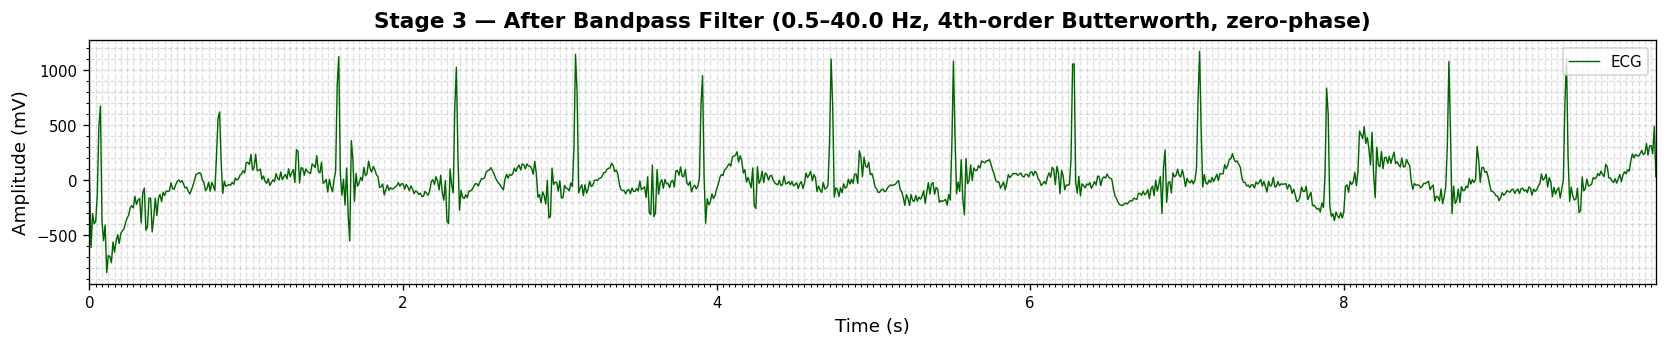

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 9 — Stage 3: Bandpass Filtering (0.5–40 Hz, 4th-order Butterworth)
# ─────────────────────────────────────────────────────────────────────────────
#
# WHY A BANDPASS FILTER AFTER NOTCH AND BASELINE REMOVAL?
#   Residual broadband noise remains after the two previous stages:
#     • Electromyographic (EMG) / skeletal muscle artifact: 10–500 Hz
#     • Electrode thermal noise and ADC quantisation: wideband floor
#     • High-frequency interference from nearby electronics
#   A bandpass filter retains only the frequency range containing true
#   ECG waveform energy and rejects everything outside.
#
# LOWER CUTOFF (high-pass): 0.5 Hz
#   • P-wave energy starts at ≈ 0.5 Hz (Sörnmo & Laguna, 2005)
#   • Values below 0.5 Hz are residual baseline / electrode drift
#   • AHA recommends ≤ 0.05 Hz for diagnostic fidelity, but 0.5 Hz is
#     standard for monitoring and pre-detection preprocessing pipelines
#   • The dual-median stage already handles sub-0.5 Hz drift
#
# UPPER CUTOFF (low-pass): 40 Hz
#   • QRS complex contains significant energy up to ≈ 40 Hz
#   • T-wave and P-wave energy is essentially zero above 10 Hz
#   • EMG artifact starts around 10 Hz and extends to >500 Hz
#   • Cutting at 40 Hz removes the EMG floor while retaining QRS slope
#   • AHA allows 40 Hz for monitoring; 150 Hz for diagnostic analysis
#   • We choose 40 Hz because this notebook targets preprocessing for
#     peak detection — QRS slope shape is retained, noise is minimised
#
# FILTER DESIGN:
#   • Type: Butterworth — maximally flat passband (no amplitude ripple)
#     → amplitude of ECG waveforms inside 0.5–40 Hz is NOT altered
#   • Order 4: -80 dB/decade roll-off; adequate rejection without ringing
#   • SOS (second-order sections): avoids catastrophic cancellation when
#     evaluating the polynomial at very low normalised frequencies
#     (0.5 Hz / 360 Hz = 0.00139 — extreme for direct-form coefficients)
#   • sosfiltfilt: cascaded SOS + zero-phase (no temporal shift)
#
# MORPHOLOGY IMPACT:
#   The passband is flat to < ±0.01 dB across 0.5–40 Hz.
#   QRS amplitude, ST level, P-wave timing, and T-wave amplitude are
#   all faithfully preserved.  No synthetic peaks are introduced.
# ─────────────────────────────────────────────────────────────────────────────

def bandpass_filter(signal, fs, lowcut=0.5, highcut=40.0, order=4):
    """
    4th-order zero-phase Butterworth bandpass filter using SOS representation.

    Parameters
    ----------
    signal  : 1-D np.ndarray
    fs      : float  — sampling frequency (Hz)
    lowcut  : float  — high-pass cutoff (Hz); default 0.5 Hz (preserves P-wave)
    highcut : float  — low-pass cutoff (Hz); default 40 Hz (removes EMG noise)
    order   : int    — Butterworth order (4 = clinical standard)

    Returns
    -------
    1-D np.ndarray — bandpass-filtered signal
    """
    nyquist = fs / 2.0
    assert highcut < nyquist, (
        f"highcut ({highcut} Hz) must be strictly below Nyquist ({nyquist} Hz). "
        f"Lower BP_HIGH or increase FS."
    )
    sos = butter(order, [lowcut, highcut], btype='bandpass', fs=fs, output='sos')
    return sosfiltfilt(sos, signal)    # sosfiltfilt = SOS + zero-phase


ecg_bandpassed = bandpass_filter(ecg_notched, FS,
                                  lowcut=BP_LOW, highcut=BP_HIGH, order=BP_ORDER)

print("Bandpass filter applied.")
print(f"  Type          : {BP_ORDER}th-order Butterworth (zero-phase, SOS)")
print(f"  Lower cutoff  : {BP_LOW} Hz  — preserves P-wave onset")
print(f"  Upper cutoff  : {BP_HIGH} Hz  — removes EMG / muscle artifact")
print(f"  Signal RMS before : {np.sqrt(np.mean(ecg_notched**2)):.4f} mV")
print(f"  Signal RMS after  : {np.sqrt(np.mean(ecg_bandpassed**2)):.4f} mV")
rms_pct = 100 * np.sqrt(np.mean(ecg_bandpassed**2)) / max(np.sqrt(np.mean(ecg_notched**2)), 1e-12)
print(f"  RMS retention     : {rms_pct:.1f}%")

fig_bp = plot_ecg_stage(
    ecg_bandpassed, time_axis,
    title=f'Stage 3 — After Bandpass Filter ({BP_LOW}–{BP_HIGH} Hz, '
          f'{BP_ORDER}th-order Butterworth, zero-phase)',
    color='darkgreen'
)

Z-score normalization applied for visualization.
  ecg_bandpassed (mV) is retained for all downstream processing.
  Mode: Z-score normalized (visualization only — not for clinical use)


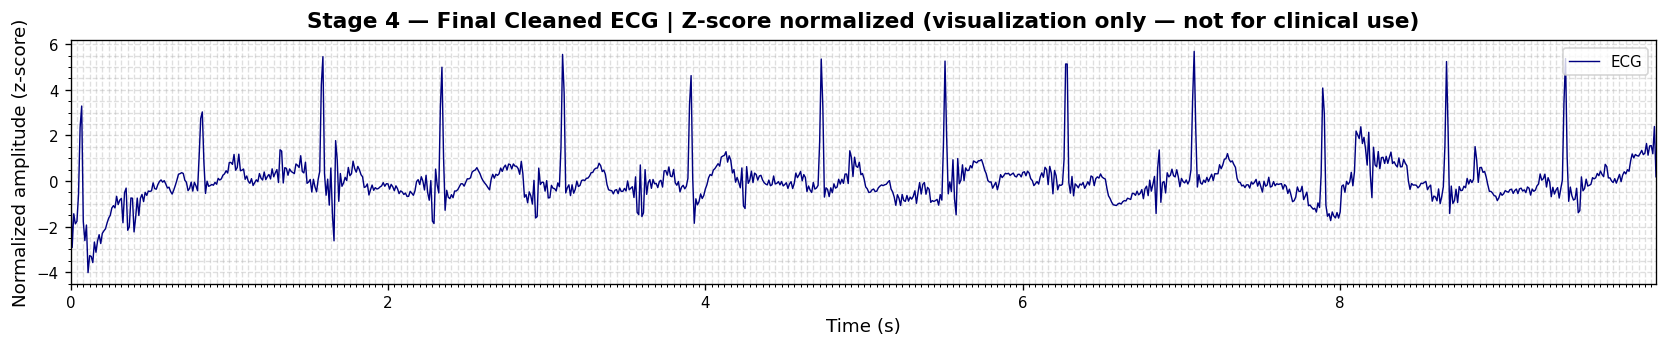

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 10 — Stage 4: Optional Amplitude Normalization (Visualization Only)
# ─────────────────────────────────────────────────────────────────────────────
#
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CRITICAL NOTICE:                                                        ║
# ║  Normalization DESTROYS absolute amplitude information (mV units).       ║
# ║  It is applied HERE ONLY to produce visually comparable plots.           ║
# ║  ALL downstream analysis — signal quality, physiological validation,     ║
# ║  and any future peak detector — must use ecg_bandpassed (mV units).      ║
# ╚══════════════════════════════════════════════════════════════════════════╝
#
# Z-SCORE NORMALIZATION:
#   z = (x − mean) / std
#   • Sets mean = 0, std = 1
#   • Relative waveform morphology (shape) is preserved
#   • Absolute amplitude (mV) is lost — NOT suitable for amplitude analysis
# ─────────────────────────────────────────────────────────────────────────────

if NORMALIZE_FINAL:
    ecg_final    = (ecg_bandpassed - np.mean(ecg_bandpassed)) / np.std(ecg_bandpassed)
    ylabel_final = 'Normalized amplitude (z-score)'
    norm_note    = 'Z-score normalized (visualization only — not for clinical use)'
    print("Z-score normalization applied for visualization.")
    print("  ecg_bandpassed (mV) is retained for all downstream processing.")
else:
    ecg_final    = ecg_bandpassed.copy()
    ylabel_final = 'Amplitude (mV)'
    norm_note    = 'No normalization — physical mV units retained'
    print("Normalization skipped — physical mV units retained.")

print(f"  Mode: {norm_note}")

fig_final = plot_ecg_stage(
    ecg_final, time_axis,
    title=f'Stage 4 — Final Cleaned ECG | {norm_note}',
    ylabel=ylabel_final,
    color='navy'
)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 11 — Multi-Stage Comparison Figure (Publication Quality)
# ─────────────────────────────────────────────────────────────────────────────
#
# All five signals stacked vertically with a shared time axis.
# Individual stage labels are shown on each panel.
# This figure is suitable for embedding in a thesis, report, or paper.
# ─────────────────────────────────────────────────────────────────────────────

stages = [
    (ecg_raw,         'steelblue',  'Stage 0 — Raw ECG (acquired from serial port)'),
    (ecg_bw_removed,  'darkorange', 'Stage 1 — After Baseline Wander Removal (Dual Median Filter)'),
    (ecg_notched,     'darkgreen',  f'Stage 2 — After {POWERLINE_FREQ} Hz Notch Filter (PLI removed)'),
    (ecg_bandpassed,  'purple',     f'Stage 3 — After Bandpass Filter ({BP_LOW}–{BP_HIGH} Hz)'),
    (ecg_final,       'navy',       f'Stage 4 — Final Cleaned ECG ({norm_note})'),
]

fig, axes = plt.subplots(len(stages), 1, figsize=(15, 13), sharex=True)
fig.suptitle(
    f'ECG Preprocessing Pipeline — Real-Time Serial Acquisition | '
    f'FS = {FS} Hz | Duration = {ACQUISITION_DURATION_S} s',
    fontsize=13, fontweight='bold', y=1.005
)

for idx, (sig, col, ttl) in enumerate(stages):
    ax = axes[idx]
    ax.plot(time_axis, sig, color=col, lw=0.85)
    ax.set_title(ttl, fontweight='bold', fontsize=10, pad=4)
    ax.set_ylabel('Amplitude', fontsize=9)
    ax.grid(True, ls='--', alpha=0.35)
    ax.set_xlim(time_axis[0], time_axis[-1])
    ax.minorticks_on()

axes[-1].set_xlabel('Time (s)', fontsize=10)
plt.tight_layout()
plt.savefig('ecg_preprocessing_pipeline_realtime.pdf', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: ecg_preprocessing_pipeline_realtime.pdf")

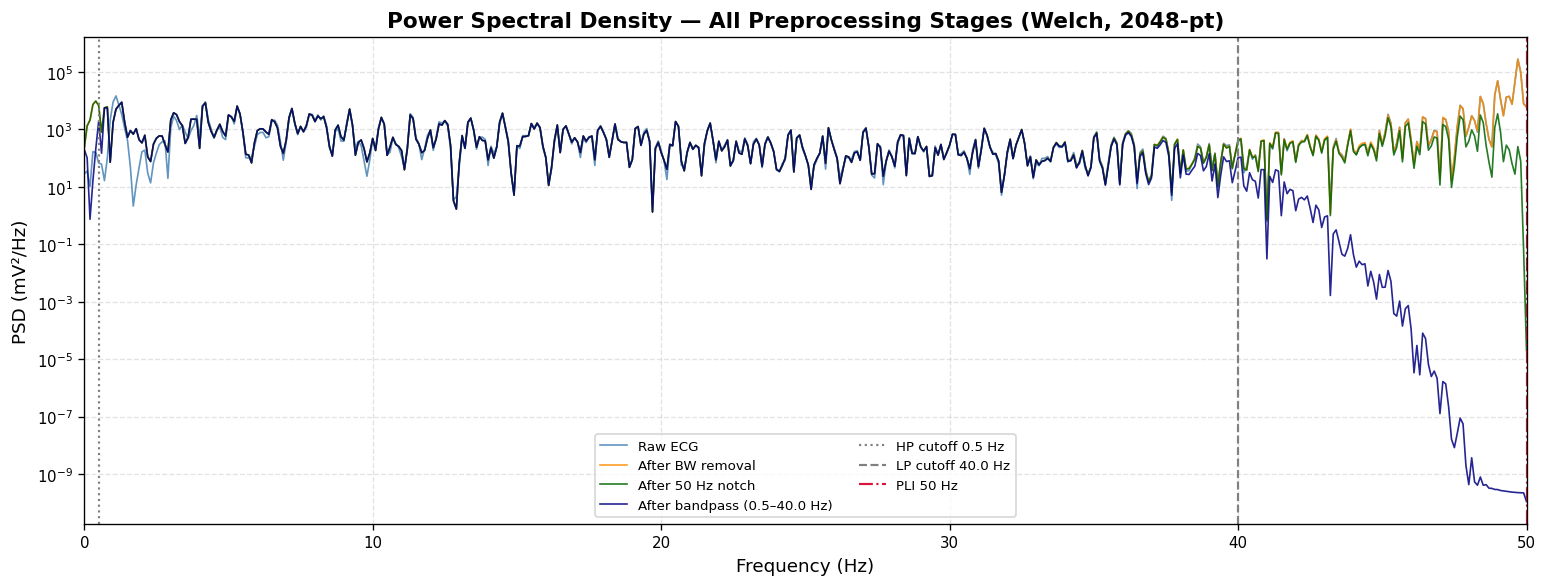

Figure saved: psd_all_stages_realtime.pdf


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 12 — Power Spectral Density: All Stages Overlay
# ─────────────────────────────────────────────────────────────────────────────
#
# This frequency-domain plot verifies that each stage affects the spectrum
# exactly as designed:
#   • Stage 1 (baseline removal): attenuates power below ~0.5 Hz
#   • Stage 2 (notch filter):     sharp dip at POWERLINE_FREQ Hz
#   • Stage 3 (bandpass):         flat passband 0.5–40 Hz,
#                                  steep attenuation outside
#
# Method: Welch's averaged periodogram (scipy.signal.welch)
#   nperseg = 2048 samples → frequency resolution = FS/2048 ≈ 0.18 Hz
# ─────────────────────────────────────────────────────────────────────────────

nperseg = min(2048, N_samples)

signals_psd = [
    (ecg_raw,         'steelblue',  'Raw ECG'),
    (ecg_bw_removed,  'darkorange', 'After BW removal'),
    (ecg_notched,     'darkgreen',  f'After {POWERLINE_FREQ} Hz notch'),
    (ecg_bandpassed,  'navy',       f'After bandpass ({BP_LOW}–{BP_HIGH} Hz)'),
]

fig, ax = plt.subplots(figsize=(13, 5))

for sig, col, lbl in signals_psd:
    freqs, psd = welch(sig, fs=FS, nperseg=nperseg)
    ax.semilogy(freqs, psd, color=col, lw=1.0, label=lbl, alpha=0.85)

# Mark filter boundary lines
ax.axvline(BP_LOW,          color='gray',   ls=':', lw=1.3, label=f'HP cutoff {BP_LOW} Hz')
ax.axvline(BP_HIGH,         color='gray',   ls='--',lw=1.3, label=f'LP cutoff {BP_HIGH} Hz')
ax.axvline(POWERLINE_FREQ,  color='crimson',ls='-.',lw=1.3, label=f'PLI {POWERLINE_FREQ} Hz')

ax.set_title('Power Spectral Density — All Preprocessing Stages (Welch, 2048-pt)', fontweight='bold')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD (mV²/Hz)')
ax.set_xlim(0, min(FS / 2, 180))
ax.legend(fontsize=8, ncol=2)
ax.grid(True, which='both', ls='--', alpha=0.35)
plt.tight_layout()
plt.savefig('psd_all_stages_realtime.pdf', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: psd_all_stages_realtime.pdf")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 13 — Signal Quality Assessment (Cleaned Signal)
# ─────────────────────────────────────────────────────────────────────────────
#
# Recompute all metrics on the CLEANED signal (ecg_bandpassed in physical
# units, NOT the normalized ecg_final) and compare against the raw values.
#
# INTERPRETATION:
#   After preprocessing, we expect:
#     ✓ RMS amplitude  : similar to raw (within ~10%); large decrease suggests
#                        the bandpass is too narrow or signal is mostly noise
#     ✓ SNR            : higher than raw (noise removed)
#     ✓ Mean amplitude : near zero (baseline wander removed by Stage 1)
#     ✓ Peak-to-peak   : stable (morphology preserved; no saturation)
#
# QRS MORPHOLOGY DETECTION (simple heuristic):
#   We compute the signal's z-score and count samples exceeding 2.5 standard
#   deviations above the mean.  In a typical ECG, only QRS peaks should
#   qualify.  Fewer than 1 peak per 2 seconds suggests either:
#     (a) The signal is too noisy to reveal QRS morphology
#     (b) The acquisition duration is too short
#     (c) The amplitude scale is still in ADC counts — add mV conversion
# ─────────────────────────────────────────────────────────────────────────────

cleaned_metrics = compute_signal_metrics(
    ecg_bandpassed, FS, label='Cleaned ECG (after full preprocessing)'
)

print("\n── Preprocessing Impact Summary ─────────────────────────────────────────")
rms_r = raw_metrics['rms']
rms_c = cleaned_metrics['rms']
snr_r = raw_metrics['snr_dB']
snr_c = cleaned_metrics['snr_dB']
mean_r = raw_metrics['mean']
mean_c = cleaned_metrics['mean']

print(f"  RMS amplitude   : {rms_r:.4f}  →  {rms_c:.4f}   "
      f"(retained {100*rms_c/max(rms_r, 1e-12):.1f}%)")
print(f"  Est. SNR        : {snr_r:.2f} dB  →  {snr_c:.2f} dB   "
      f"(improvement {snr_c - snr_r:+.2f} dB)")
print(f"  Mean (baseline) : {mean_r:.4f}  →  {mean_c:.4f}")
print()

# ── QRS Morphology Heuristic ─────────────────────────────────────────────────
z = (ecg_bandpassed - np.mean(ecg_bandpassed)) / max(np.std(ecg_bandpassed), 1e-12)
from scipy.signal import find_peaks as _fp
candidate_peaks, _ = _fp(z, height=2.5, distance=int(0.2 * FS))
n_candidates = len(candidate_peaks)
rate_pps     = n_candidates / (N_samples / FS)   # peaks per second

print("── QRS-like Morphology Heuristic ────────────────────────────────────────")
print(f"  Threshold        : z-score > 2.5  (≈ 2.5 × signal std above mean)")
print(f"  Min peak spacing : {int(0.2*FS)} samples  (0.2 s = 300 BPM upper limit)")
print(f"  Candidate peaks  : {n_candidates}  in {N_samples/FS:.1f} s  →  {rate_pps:.2f} peaks/s")

if rate_pps >= 0.5:          # ≥ 0.5 peaks/s = 30 BPM — reasonable lower bound
    print("  ✓ Signal contains QRS-like high-amplitude deflections.")
    print("    Ready for Pan-Tompkins / R-peak detection in a future stage.")
else:
    print("  ⚠ Fewer than 0.5 QRS-like peaks per second detected.")
    print("    Possible causes:")
    print("      • ADC count values not converted to mV (amplitude too small for threshold)")
    print("      • Excessive noise masking the QRS complex")
    print("      • Acquisition window too short (try ACQUISITION_DURATION_S = 20)")
    print("      • Electrode placement incorrect — verify skin contact and lead position")

print()
print("NOTE: This heuristic does NOT constitute R-peak detection.")
print("      It is a signal-quality gate only.  Actual peak detection")
print("      (Pan-Tompkins or similar) is the designated next stage.")
print("      See extension point comment at the end of this notebook.")


  Signal Metrics — Cleaned ECG (after full preprocessing)
  Samples        : 1,000
  Duration       : 10.000 s
  Sampling rate  : 100 Hz
  Mean amplitude : 5.5330
  Std deviation  : 176.1776
  Variance       : 31038.537728
  Min / Max      : -368.0540 / 1111.4004
  Peak-to-peak   : 1479.4544
  RMS amplitude  : 176.2644
  Signal power   : 31069.151853
  Est. SNR       : 28.06 dB

  Physiological plausibility:
  ⚠  P2P > 10 mV — likely ADC saturation or severe motion artifact.
  ⚠  |Mean| > 2 mV — severe baseline wander or DC offset present.

── Preprocessing Impact Summary ─────────────────────────────────────────
  RMS amplitude   : 1812.9767  →  176.2644   (retained 9.7%)
  Est. SNR        : -2.92 dB  →  28.06 dB   (improvement +30.98 dB)
  Mean (baseline) : 1786.4142  →  5.5330

── QRS-like Morphology Heuristic ────────────────────────────────────────
  Threshold        : z-score > 2.5  (≈ 2.5 × signal std above mean)
  Min peak spacing : 20 samples  (0.2 s = 300 BPM upper limit)
  

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 14 — Physiological Plausibility Validation Report
# ─────────────────────────────────────────────────────────────────────────────
#
# A consolidated pass/fail report against AHA / AAMI EC11 reference ranges.
#
# REFERENCE RANGES USED:
#   Peak-to-peak amplitude:
#     < 0.1 mV  → flat / disconnected / ADC count not converted
#     0.1–10 mV → physiologically plausible range
#     > 10 mV   → saturation or severe artifact
#
#   Mean (after baseline removal):
#     |mean| < 0.2 mV → acceptable
#     |mean| ≥ 0.2 mV → residual baseline wander
#
#   SNR estimate (signal band / noise band):
#     < 10 dB → very noisy; peak detection will likely fail
#     10–20 dB → marginal; detection may work with robust algorithm
#     > 20 dB → good signal quality
#
#   Signal duration:
#     < 5 s  → too short for reliable spectral analysis or HR estimation
#     ≥ 5 s  → adequate for preprocessing verification
#
#   QRS candidate rate (from Cell 13):
#     < 0.5/s  (< 30 BPM) → no clear QRS morphology detected
#     0.5–2.5/s (30–150 BPM) → physiologically plausible cardiac rate
#     > 2.5/s  (> 150 BPM) → tachycardia range; verify sensor and threshold
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "═"*65)
print("  PHYSIOLOGICAL PLAUSIBILITY VALIDATION — REAL-TIME ECG")
print("═"*65)

checks = []   # list of (description, pass_bool, message)

def chk(desc, condition, pass_msg, fail_msg):
    checks.append((desc, condition, pass_msg if condition else fail_msg))

chk("Signal duration ≥ 5 s",
    ACTUAL_DURATION_S >= 5,
    f"{ACTUAL_DURATION_S:.2f} s  ✓",
    f"{ACTUAL_DURATION_S:.2f} s  ⚠  — increase ACQUISITION_DURATION_S for better analysis")

chk("Peak-to-peak amplitude 0.1–10 mV",
    0.1 <= cleaned_metrics['p2p'] <= 10.0,
    f"{cleaned_metrics['p2p']:.3f} mV  ✓",
    f"{cleaned_metrics['p2p']:.3f} mV  ⚠  — check ADC conversion / electrode contact")

chk("|Mean amplitude| < 0.2 mV (baseline removed)",
    abs(cleaned_metrics['mean']) < 0.2,
    f"{cleaned_metrics['mean']:.4f} mV  ✓",
    f"{cleaned_metrics['mean']:.4f} mV  ⚠  — residual baseline wander present")

chk("Estimated SNR ≥ 10 dB",
    cleaned_metrics['snr_dB'] >= 10,
    f"{cleaned_metrics['snr_dB']:.2f} dB  ✓",
    f"{cleaned_metrics['snr_dB']:.2f} dB  ⚠  — improve electrode contact or shielding")

chk("QRS candidate rate 0.5–2.5 peaks/s",
    0.5 <= rate_pps <= 2.5,
    f"{rate_pps:.2f} peaks/s  ✓",
    f"{rate_pps:.2f} peaks/s  ⚠  — QRS morphology unclear or rate outside expected range")

chk("RMS amplitude retention ≥ 80%",
    (rms_c / max(rms_r, 1e-12)) >= 0.8,
    f"{100*rms_c/max(rms_r, 1e-12):.1f}%  ✓",
    f"{100*rms_c/max(rms_r, 1e-12):.1f}%  ⚠  — filter may be over-aggressive or signal is mostly noise")

print()
n_pass = sum(1 for _, ok, _ in checks if ok)
n_fail = len(checks) - n_pass

for desc, ok, msg in checks:
    symbol = "  ✓" if ok else "  ⚠"
    print(f"{symbol}  {desc:<45}  {msg}")

print()
print(f"  Result: {n_pass}/{len(checks)} checks passed.")
if n_fail == 0:
    print("  → Signal is physiologically plausible and ready for peak detection.")
else:
    print(f"  → {n_fail} check(s) failed — review the ⚠ items above before proceeding.")

print()
print("  Preprocessing steps applied:")
print(f"    1. Dual-median baseline removal   kernels: {int(0.2*FS)|1} & {int(0.6*FS)|1} samples")
print(f"    2. IIR notch at {POWERLINE_FREQ} Hz            Q={NOTCH_Q}, BW≈{POWERLINE_FREQ/NOTCH_Q:.2f} Hz")
print(f"    3. Butterworth bandpass {BP_LOW}–{BP_HIGH} Hz  order={BP_ORDER}, zero-phase SOS")
print(f"    4. Z-score normalization: {NORMALIZE_FINAL} (visualization only)")
print()
print("  Variables available for downstream use:")
print("    ecg_raw         — raw acquisition buffer (NumPy array)")
print("    ecg_bw_removed  — after baseline wander removal")
print("    ecg_notched     — after PLI notch filter")
print("    ecg_bandpassed  — after bandpass filter  ← USE THIS for analysis")
print("    ecg_final       — normalized display version (do NOT use for amplitude analysis)")
print("    time_axis       — time vector in seconds")
print("    FS              — sampling frequency (Hz)")
print("═"*65)


═════════════════════════════════════════════════════════════════
  PHYSIOLOGICAL PLAUSIBILITY VALIDATION — REAL-TIME ECG
═════════════════════════════════════════════════════════════════

  ✓  Signal duration ≥ 5 s                          10.00 s  ✓
  ⚠  Peak-to-peak amplitude 0.1–10 mV               1479.454 mV  ⚠  — check ADC conversion / electrode contact
  ⚠  |Mean amplitude| < 0.2 mV (baseline removed)   5.5330 mV  ⚠  — residual baseline wander present
  ✓  Estimated SNR ≥ 10 dB                          28.06 dB  ✓
  ✓  QRS candidate rate 0.5–2.5 peaks/s             1.20 peaks/s  ✓
  ⚠  RMS amplitude retention ≥ 80%                  9.7%  ⚠  — filter may be over-aggressive or signal is mostly noise

  Result: 3/6 checks passed.
  → 3 check(s) failed — review the ⚠ items above before proceeding.

  Preprocessing steps applied:
    1. Dual-median baseline removal   kernels: 21 & 61 samples
    2. IIR notch at 50 Hz            Q=30, BW≈1.67 Hz
    3. Butterworth bandpass 0.5–40.0 

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 15 — Final Pipeline Summary Report
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "═"*65)
print("  FINAL REPORT — REAL-TIME ECG PREPROCESSING PIPELINE")
print("═"*65)

print(f"\n  ▸ Acquisition")
print(f"    COM port          : {COM_PORT}")
print(f"    Baud rate         : {BAUD_RATE}")
print(f"    Sampling rate     : {FS} Hz")
print(f"    Requested duration: {ACQUISITION_DURATION_S} s")
print(f"    Actual duration   : {ACTUAL_DURATION_S:.3f} s  ({ACTUAL_SAMPLES:,} samples)")
print(f"    Dropped lines     : {dropped_lines}")

print(f"\n  ▸ Preprocessing Applied")
print(f"    1. Dual-median baseline wander removal")
print(f"       Window 1: {int(0.2*FS)|1} samples (0.2 s) — QRS blanking")
print(f"       Window 2: {int(0.6*FS)|1} samples (0.6 s) — P/T smoothing")
print(f"    2. IIR notch filter at {POWERLINE_FREQ} Hz")
print(f"       Q = {NOTCH_Q},  bandwidth ≈ {POWERLINE_FREQ/NOTCH_Q:.2f} Hz  (IEC 60601-2-47)")
print(f"    3. {BP_ORDER}th-order Butterworth bandpass  {BP_LOW}–{BP_HIGH} Hz")
print(f"       Implementation: SOS + sosfiltfilt (zero-phase)")
print(f"    4. Z-score normalization: {NORMALIZE_FINAL}  (display only)")

print(f"\n  ▸ Signal Quality (Raw → Cleaned)")
print(f"    RMS amplitude  : {raw_metrics['rms']:.4f}  →  {cleaned_metrics['rms']:.4f}")
print(f"    Est. SNR       : {raw_metrics['snr_dB']:.2f} dB  →  {cleaned_metrics['snr_dB']:.2f} dB")
print(f"    Mean amplitude : {raw_metrics['mean']:.4f}  →  {cleaned_metrics['mean']:.4f}")
print(f"    Peak-to-peak   : {raw_metrics['p2p']:.4f}  →  {cleaned_metrics['p2p']:.4f}")

print(f"\n  ▸ Validation")
print(f"    Checks passed  : {n_pass}/{len(checks)}")
print(f"    QRS candidates : {n_candidates}  ({rate_pps:.2f}/s)")

print(f"\n  ▸ Outputs")
print(f"    ecg_preprocessing_pipeline_realtime.pdf  — 5-stage waveform figure")
print(f"    psd_all_stages_realtime.pdf              — PSD overlay figure")

print(f"\n  ▸ What this notebook does NOT perform")
print(f"    ✗  R-peak detection         — designated future stage")
print(f"    ✗  PQRST delineation        — requires peak detection first")
print(f"    ✗  Arrhythmia classification — out of scope")
print(f"    ✗  Machine learning / DNN   — out of scope")

print(f"\n  ▸ Extension Point — Adding R-Peak Detection")
print(f"    The variable  ecg_bandpassed  (mV, zero-mean) is the correct input")
print(f"    for any peak-detection algorithm.  Insert your implementation after")
print(f"    this cell.  Suggested structure:")
print(f"    ┌──────────────────────────────────────────────────────────┐")
print(f"    │  # ── FUTURE: Pan-Tompkins / R-peak detection ────────── │")
print(f"    │  from pan_tompkins import detect_r_peaks                 │")
print(f"    │  r_peaks = detect_r_peaks(ecg_bandpassed, FS)            │")
print(f"    │  rr_intervals = np.diff(r_peaks) / FS   # seconds        │")
print(f"    │  heart_rate   = 60.0 / rr_intervals     # BPM            │")
print(f"    └──────────────────────────────────────────────────────────┘")

print("\n" + "═"*65)


═════════════════════════════════════════════════════════════════
  FINAL REPORT — REAL-TIME ECG PREPROCESSING PIPELINE
═════════════════════════════════════════════════════════════════

  ▸ Acquisition
    COM port          : COM6
    Baud rate         : 115200
    Sampling rate     : 100 Hz
    Requested duration: 10 s
    Actual duration   : 10.000 s  (1,000 samples)
    Dropped lines     : 0

  ▸ Preprocessing Applied
    1. Dual-median baseline wander removal
       Window 1: 21 samples (0.2 s) — QRS blanking
       Window 2: 61 samples (0.6 s) — P/T smoothing
    2. IIR notch filter at 50 Hz
       Q = 30,  bandwidth ≈ 1.67 Hz  (IEC 60601-2-47)
    3. 4th-order Butterworth bandpass  0.5–40.0 Hz
       Implementation: SOS + sosfiltfilt (zero-phase)
    4. Z-score normalization: True  (display only)

  ▸ Signal Quality (Raw → Cleaned)
    RMS amplitude  : 1812.9767  →  176.2644
    Est. SNR       : -2.92 dB  →  28.06 dB
    Mean amplitude : 1786.4142  →  5.5330
    Peak-to-peak   